# 03 · Ratio Metrics (CTR)

Correct statistical tests for ratio metrics, where randomisation is by user but the metric is computed from views. Each method is checked on 10,000 simulated A/A and A/B experiments:
* Poisson bootstrap
* Bucketization (t-test and Mann–Whitney)
* Delta method
* Linearization
* Smoothed CTR and intra-user-correlation-aware weights

In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import scipy
from scipy.stats import norm, probplot, rankdata
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from typing import Tuple, Dict, Optional, Set, List
import os
import hashlib

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from tqdm import tqdm
from scipy.stats import kstest

from scipy.stats import ttest_ind, mannwhitneyu

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def generation(
    N=10**3,          # number of users in each group
    experiments=10000,  # number of A/A and A/B experiments to generate
    mu=1, # skewness of views
    sigma2=0.5,
    success_rate=0.02,  # global CTR in group A
    uplift=0.2,  # for group B
    beta=1000
):

    # Generate views (assumption: the treatment does not affect views)
    views_a_1 = np.exp(norm(mu, sigma2).rvs(experiments * N)
                       ).astype(np.int64).reshape(experiments, N) + 1
    views_a_2 = np.exp(norm(mu, sigma2).rvs(experiments * N)
                       ).astype(np.int64).reshape(experiments, N) + 1
    views_b = np.exp(norm(mu, sigma2).rvs(experiments * N)
                     ).astype(np.int64).reshape(experiments, N) + 1

    views_a_1 = np.absolute(views_a_1)
    views_a_2 = np.absolute(views_a_2)
    views_b = np.absolute(views_b)

    # global CTR in groups A1 and A2
    alpha_a = success_rate * beta / (1 - success_rate)
    success_rate_a_1 = stats.beta(alpha_a, beta).rvs(
        experiments * N).reshape(experiments, N)
    success_rate_a_2 = stats.beta(alpha_a, beta).rvs(
        experiments * N).reshape(experiments, N)

    # global CTR in group B
    alpha_b = success_rate * (1 + uplift) * beta / \
        (1 - success_rate * (1 + uplift))
    success_rate_b = stats.beta(alpha_b, beta).rvs(
        experiments * N).reshape(experiments, N)

    # Distribution of clicks in the groups
    clicks_a_1 = stats.binom(n=views_a_1, p=success_rate_a_1).rvs()
    clicks_a_2 = stats.binom(n=views_a_2, p=success_rate_a_2).rvs()
    clicks_b = stats.binom(n=views_b, p=success_rate_b).rvs()

    return views_a_1, views_a_2, views_b, clicks_a_1, clicks_a_2, clicks_b



In [ ]:
views_a_1, views_a_2, views_b, clicks_a_1, clicks_a_2, clicks_b = generation(N=10**3, experiments=10000)

In [ ]:
views_a_1

array([[4, 2, 3, ..., 3, 3, 3],
       [2, 4, 6, ..., 2, 2, 2],
       [3, 2, 6, ..., 3, 2, 4],
       ...,
       [3, 3, 6, ..., 2, 3, 3],
       [5, 5, 4, ..., 2, 3, 3],
       [6, 5, 3, ..., 2, 5, 3]])

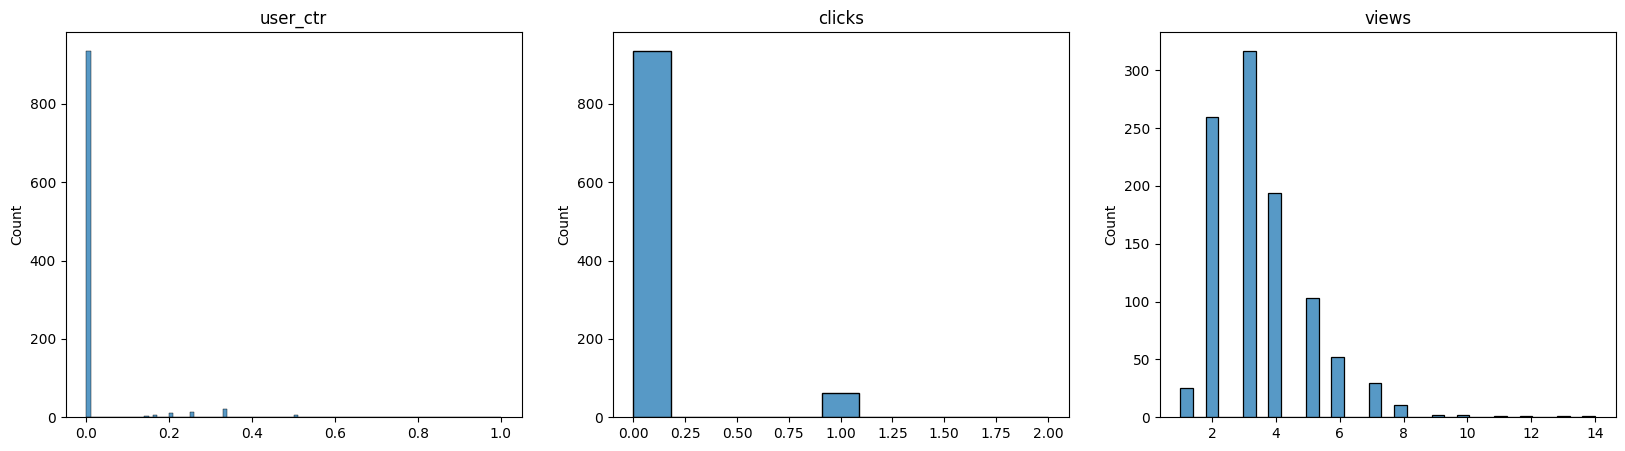

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(clicks_a_1[0] / views_a_1[0], ax=ax[0], bins=100)
sns.histplot(clicks_a_1[0], ax=ax[1])
sns.histplot(views_a_1[0], ax=ax[2])

ax[0].set_title('user_ctr')
ax[1].set_title('clicks')
ax[2].set_title('views')
plt.show()

# Utils

In [ ]:
# def sim_test(
#         groups_1, groups_2,
#         _test=ttest_ind,
# ):
#     # A/A simulations
#     lst_p_vals = []
#     for exp1, exp2 in zip(groups_1, groups_2):
#         test_statistic, p_val = _test(exp1, exp2)
#         lst_p_vals.append(p_val)

#     ks_statistic, p_value = kstest(lst_p_vals, 'uniform')
#     # print(f"KS-test | P-value: {p_value}")

#     return np.array(lst_p_vals)


def plot_cdf(data: np.ndarray, label: str, ax: Axes, color: str = 'green', linewidth=2):
    sorted_data = np.sort(data)
    position = scipy.stats.rankdata(sorted_data, method='ordinal')
    cdf = position / data.shape[0]

    sorted_data = np.hstack((sorted_data, 1))
    cdf = np.hstack((cdf, 1))

    return ax.plot(
        sorted_data,
        cdf,
        color=color,
        linestyle='-',
        label=label,
        linewidth=linewidth
    )

# Methods

In [ ]:
def bootstrap(ctrs_0, weights_0, ctrs_1, weights_1, B=2000):
    pass


def poisson_bootstrap(ctrs_0, weights_0, ctrs_1, weights_1, B=2000):
    """
    ctrs_x - per-user CTR
    weights_x - number of views
    0 - control group
    1 - test group
    Does weighted bootstrap and calculates p-value according to the bootstraped distribution
    """

    # generate the number of draws with replacement for each user
    poisson_bootstraps = stats.poisson(1).rvs((B, ctrs_0.shape[1])).astype(np.int64)

    # generate weighted resamples
    values_0 = np.matmul(ctrs_0 * weights_0, poisson_bootstraps.T)
    weights_0 = np.matmul(weights_0, poisson_bootstraps.T)

    values_1 = np.matmul(ctrs_1 * weights_1, poisson_bootstraps.T)
    weights_1 = np.matmul(weights_1, poisson_bootstraps.T)

    # compute the CTR difference between groups
    deltas = values_1 / weights_1 - values_0 / weights_0

    positions = np.sum(deltas < 0, axis=1)

    return 2 * np.minimum(positions, B - positions) / B

### Poisson bootstrap step by step

In [ ]:
ctrs_0 = clicks_a_1 / views_a_1
weights_0 = views_a_1
ctrs_1 = clicks_a_2 / views_a_2
weights_1 = views_a_2

B=2000

# generate the number of draws with replacement for each user
poisson_bootstraps = stats.poisson(1).rvs((B, ctrs_0.shape[1])).astype(np.int64)

# generate weighted resamples
values_0 = np.matmul(ctrs_0 * weights_0, poisson_bootstraps.T)
weights_0 = np.matmul(weights_0, poisson_bootstraps.T)

values_1 = np.matmul(ctrs_1 * weights_1, poisson_bootstraps.T)
weights_1 = np.matmul(weights_1, poisson_bootstraps.T)

# compute the CTR difference between groups
deltas = values_1 / weights_1 - values_0 / weights_0

positions = np.sum(deltas < 0, axis=1)

2 * np.minimum(positions, B - positions) / B

array([0.92 , 0.043, 0.127, ..., 0.156, 0.516, 0.868])

In [ ]:
poisson_bootstraps

array([[2, 0, 1, ..., 1, 2, 1],
       [0, 2, 1, ..., 3, 2, 3],
       [0, 1, 4, ..., 0, 0, 1],
       ...,
       [0, 2, 0, ..., 0, 1, 0],
       [0, 2, 1, ..., 1, 1, 0],
       [0, 1, 0, ..., 1, 0, 1]])

In [ ]:
values_1.shape, weights_1.shape

((10000, 2000), (10000, 2000))

In [ ]:
values_1 / weights_1 - values_0 / weights_0

array([[ 0.00406718, -0.00625482, -0.00678895, ..., -0.00067993,
        -0.0035971 , -0.00543185],
       [ 0.00967036,  0.01680205,  0.00325515, ...,  0.00871059,
         0.00690208,  0.01367282],
       [ 0.01025188,  0.00523597,  0.00632709, ...,  0.00823518,
         0.00518326,  0.00596436],
       ...,
       [ 0.00729132,  0.00018262,  0.00544391, ...,  0.00541845,
         0.00225355,  0.00493419],
       [-0.00166904,  0.00388299,  0.00087045, ..., -0.00147931,
         0.00856606, -0.00368763],
       [ 0.00566275,  0.00415272, -0.00014889, ...,  0.00352367,
        -0.00112675,  0.00268945]])

In [ ]:
positions

array([920,  43, 127, ..., 156, 516, 868])

In [ ]:
2 * np.minimum(positions, B - positions) / B

array([0.92 , 0.043, 0.127, ..., 0.156, 0.516, 0.868])

Percentage p-values: 0.0541


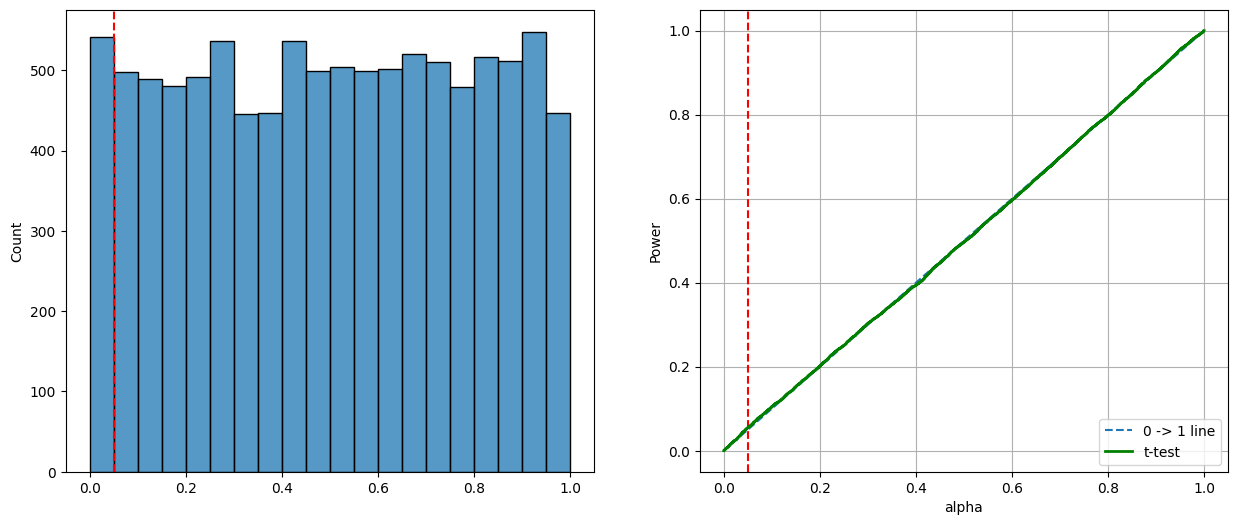

In [ ]:
p_vals = poisson_bootstrap(clicks_a_1 / views_a_1, views_a_1, clicks_a_2 / views_a_2, views_a_2)
print(f"Percentage p-values: {(p_vals < 0.05).mean()}")

# 1.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(p_vals, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2
ax[1].grid(True)
ax[1].axvline(0.05, color='r', linestyle='--')
ax[1].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('Power')
cdf = plot_cdf(p_vals,'t-test',ax[1])
legend = ax[1].legend()

plt.show()

Percentage p-values: 0.2108


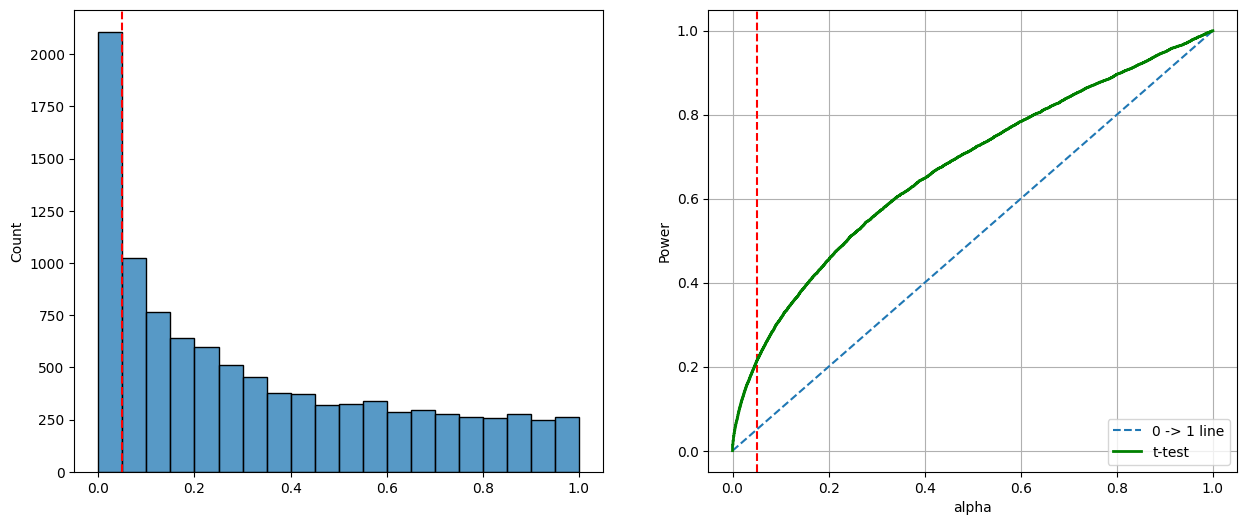

In [ ]:
p_vals = poisson_bootstrap(clicks_a_1 / views_a_1, views_a_1, clicks_b / views_b, views_b)
print(f"Percentage p-values: {(p_vals < 0.05).mean()}")

# 1.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(p_vals, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2
ax[1].grid(True)
ax[1].axvline(0.05, color='r', linestyle='--')
ax[1].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('Power')
cdf = plot_cdf(p_vals,'t-test',ax[1])
legend = ax[1].legend()

plt.show()

In [ ]:
def bucketization(ctrs_0, weights_0, ctrs_1, weights_1, B=200):
    """
    0 - control group
    1 - test group
    B - number of buckets
    Does weighted bucketization and calculates p-values for all experiments using t_test
    """

    n_experiments, n_users = ctrs_0.shape

    values_0 = np.zeros((n_experiments, B))
    values_1 = np.zeros((n_experiments, B))

    for b in np.arange(B):
        # select the indices that fall into this bucket
        ind = np.arange(b * n_users / B, b * n_users / B + n_users / B).astype(int)

        values_0[:, b] = np.sum(ctrs_0[:, ind] * weights_0[:, ind], axis=1) / np.sum(weights_0[:, ind], axis=1)
        values_1[:, b] = np.sum(ctrs_1[:, ind] * weights_1[:, ind], axis=1) / np.sum(weights_1[:, ind], axis=1)

    return values_0, values_1


In [ ]:
values_0.shape, values_1

((10000, 2000),
 array([[ 76.,  65.,  58., ...,  58.,  68.,  52.],
        [ 98., 117.,  74., ...,  92.,  93., 108.],
        [ 91.,  72.,  66., ...,  81.,  78.,  74.],
        ...,
        [ 79.,  76.,  90., ...,  83.,  75.,  85.],
        [ 65.,  73.,  69., ...,  67.,  78.,  59.],
        [ 81.,  73.,  60., ...,  86.,  60.,  72.]]))

Percentage p-values t-test: 0.0533
Percentage p-values MW: 0.0516


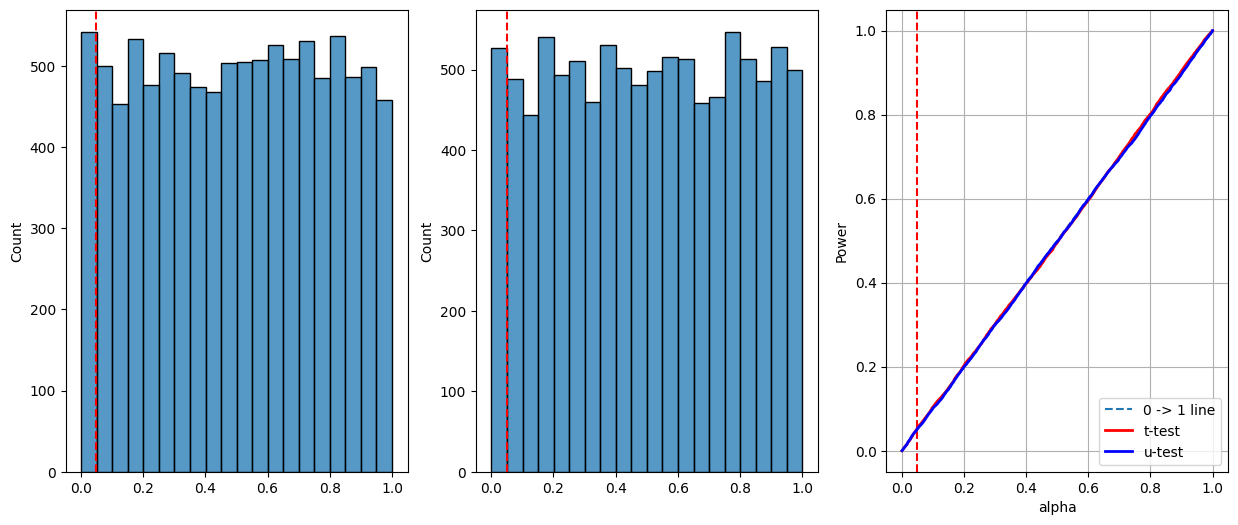

In [ ]:
values_0, values_1 = bucketization(clicks_a_1 / views_a_1, views_a_1, clicks_a_2 / views_a_2, views_a_2)
p_vals_AA_ttest = stats.ttest_ind(values_0.T, values_1.T).pvalue
p_vals_AA_mw = stats.mannwhitneyu(values_0.T, values_1.T).pvalue

print(f"Percentage p-values t-test: {(p_vals_AA_ttest < 0.05).mean()}")
print(f"Percentage p-values MW: {(p_vals_AA_mw < 0.05).mean()}")

fig, ax = plt.subplots(1, 3, figsize=(15, 6))

# 1.
sns.histplot(p_vals_AA_ttest, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2.
sns.histplot(p_vals_AA_mw, ax=ax[1], bins = 20)
ax[1].axvline(0.05, color='r', linestyle='--')

# 3.
ax[2].grid(True)
ax[2].axvline(0.05, color='r', linestyle='--')
ax[2].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[2].set_xlabel('alpha')
ax[2].set_ylabel('Power')
cdf = plot_cdf(p_vals_AA_ttest,'t-test', ax[2], color='r')
cdf = plot_cdf(p_vals_AA_mw,'u-test', ax[2], color='b')
legend = ax[2].legend()


plt.show()

Percentage p-values t-test: 0.204
Percentage p-values MW: 0.1919


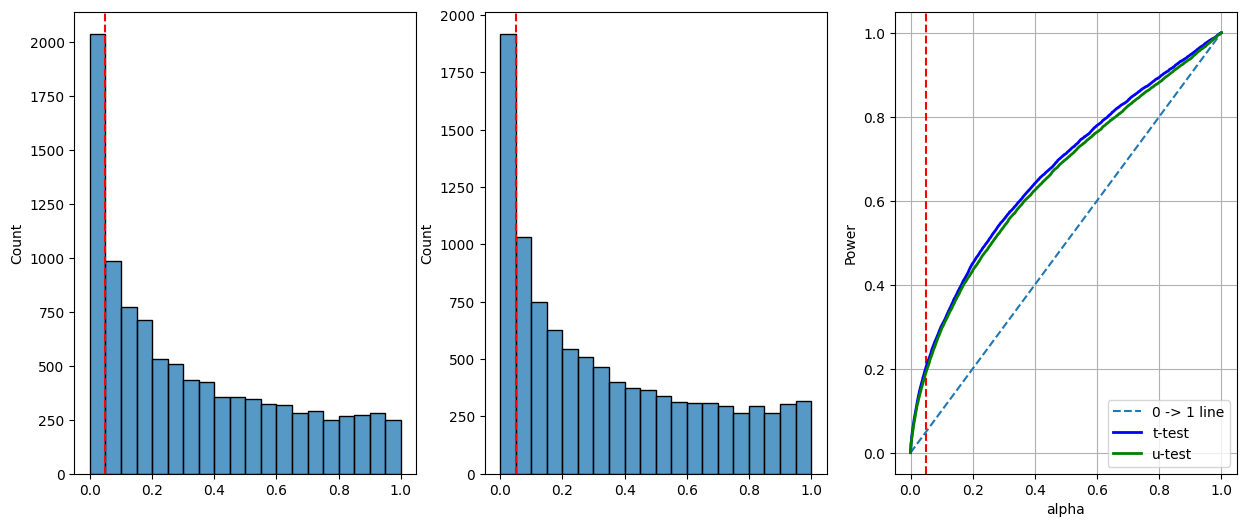

In [ ]:
values_0, values_1 = bucketization(clicks_a_1 / views_a_1, views_a_1, clicks_b / views_b, views_b)
p_vals_AA_ttest = stats.ttest_ind(values_0.T, values_1.T).pvalue
p_vals_AA_mw = stats.mannwhitneyu(values_0.T, values_1.T).pvalue

print(f"Percentage p-values t-test: {(p_vals_AA_ttest < 0.05).mean()}")
print(f"Percentage p-values MW: {(p_vals_AA_mw < 0.05).mean()}")

fig, ax = plt.subplots(1, 3, figsize=(15, 6))

# 1.
sns.histplot(p_vals_AA_ttest, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2.
sns.histplot(p_vals_AA_mw, ax=ax[1], bins = 20)
ax[1].axvline(0.05, color='r', linestyle='--')

# 3.
ax[2].grid(True)
ax[2].axvline(0.05, color='r', linestyle='--')
ax[2].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[2].set_xlabel('alpha')
ax[2].set_ylabel('Power')
cdf = plot_cdf(p_vals_AA_ttest,'t-test', ax[2], color='b')
cdf = plot_cdf(p_vals_AA_mw,'u-test', ax[2], color='g')
legend = ax[2].legend()

plt.show()

In [ ]:
len(p_vals_AA_ttest)

10000

# Delta method

In [ ]:
def delta_method_ctrs(clicks_0, views_0, clicks_1, views_1):
    """
    0 - control group
    1 - test group
    Return corrected with delta-method p-value
    """
    n_experiments, n_users = views_0.shape

    mean_clicks_0, var_clicks_0 = np.mean(clicks_0, axis=1), np.var(clicks_0, axis=1)
    mean_clicks_1, var_clicks_1 = np.mean(clicks_1, axis=1), np.var(clicks_1, axis=1)

    mean_views_0, var_views_0 = np.mean(views_0, axis=1), np.var(views_0, axis=1)
    mean_views_1, var_views_1 = np.mean(views_1, axis=1), np.var(views_1, axis=1)

    cov_0 = np.mean((clicks_0 - mean_clicks_0.reshape(-1, 1)) * (views_0 - mean_views_0.reshape(-1, 1)),
                    axis=1)
    cov_1 = np.mean((clicks_1 - mean_clicks_1.reshape(-1, 1)) * (views_1 - mean_views_1.reshape(-1, 1)),
                    axis=1)

    var_0 = var_clicks_0 / mean_views_0 ** 2 + var_views_0 * mean_clicks_0 ** 2 / mean_views_0 ** 4 - 2 * mean_clicks_0 / mean_views_0 ** 3 * cov_0
    var_1 = var_clicks_1 / mean_views_1 ** 2 + var_views_1 * mean_clicks_1 ** 2 / mean_views_1 ** 4 - 2 * mean_clicks_1 / mean_views_1 ** 3 * cov_1

    ctrs_0 = np.sum(clicks_0, axis=1) / np.sum(views_0, axis=1)
    ctrs_1 = np.sum(clicks_1, axis=1) / np.sum(views_1, axis=1)

    z_stats = (ctrs_1 - ctrs_0) / np.sqrt(var_0 / n_users + var_1 / n_users)
    p_ctr_delta = 2 * np.minimum(stats.norm(0, 1).cdf(z_stats), 1 - stats.norm(0, 1).cdf(z_stats))

    return p_ctr_delta
    # return ctrs_0, ctrs_1

Percentage p-values: 0.0528


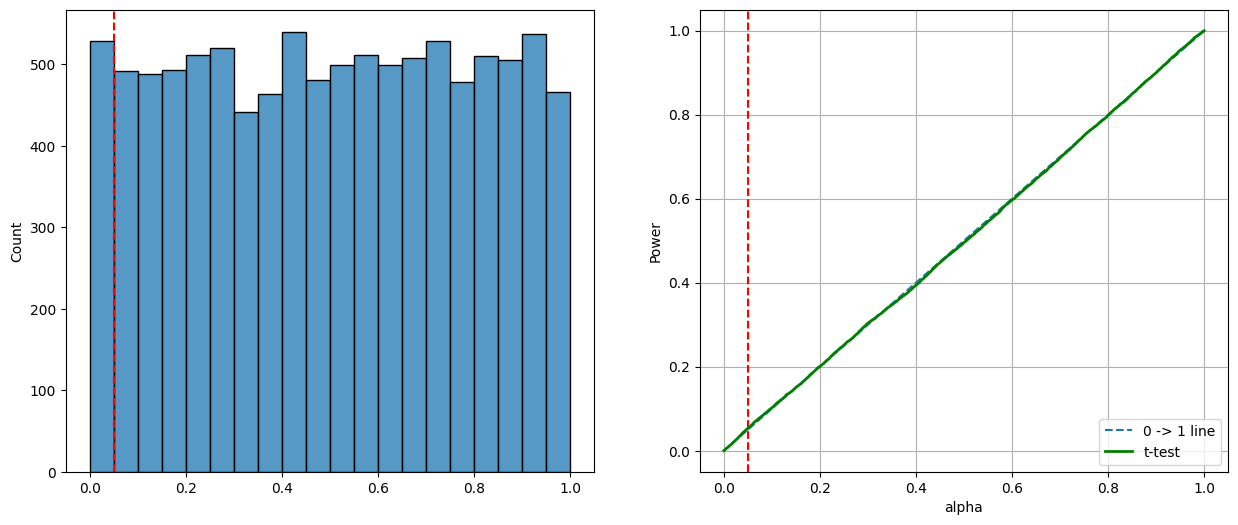

In [ ]:
p_vals = delta_method_ctrs(clicks_a_1, views_a_1, clicks_a_2, views_a_2)
# p_vals
print(f"Percentage p-values: {(p_vals < 0.05).mean()}")

# 1.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(p_vals, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2
ax[1].grid(True)
ax[1].axvline(0.05, color='r', linestyle='--')
ax[1].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('Power')
cdf = plot_cdf(p_vals,'t-test',ax[1])
legend = ax[1].legend()

plt.show()

Percentage p-values: 0.2099


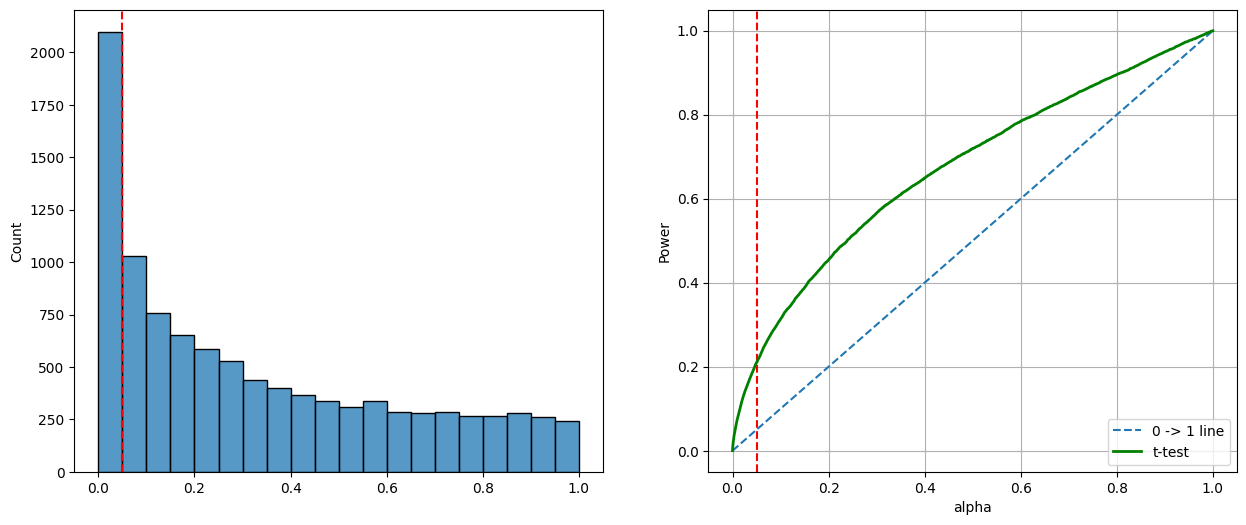

In [ ]:
p_vals = delta_method_ctrs(clicks_a_1, views_a_1, clicks_b, views_b)
# p_vals
print(f"Percentage p-values: {(p_vals < 0.05).mean()}")

# 1.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(p_vals, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2
ax[1].grid(True)
ax[1].axvline(0.05, color='r', linestyle='--')
ax[1].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('Power')
cdf = plot_cdf(p_vals,'t-test',ax[1])
legend = ax[1].legend()

plt.show()

# Linearization

In [ ]:
def linearization_of_clicks(clicks_0, views_0, clicks_1, views_1):
    """
    0 - control group
    1 - test group
    return 2 linearized arrays
    """
    k = (clicks_0.sum(axis=1) x / views_0.sum(axis=1)).reshape(-1, 1)
    L_0 = clicks_0 - k * views_0
    L_1 = clicks_1 - k * views_1
    return L_0, L_1

Percentage p-values t-test: 0.0525
Percentage p-values MW: 0.048


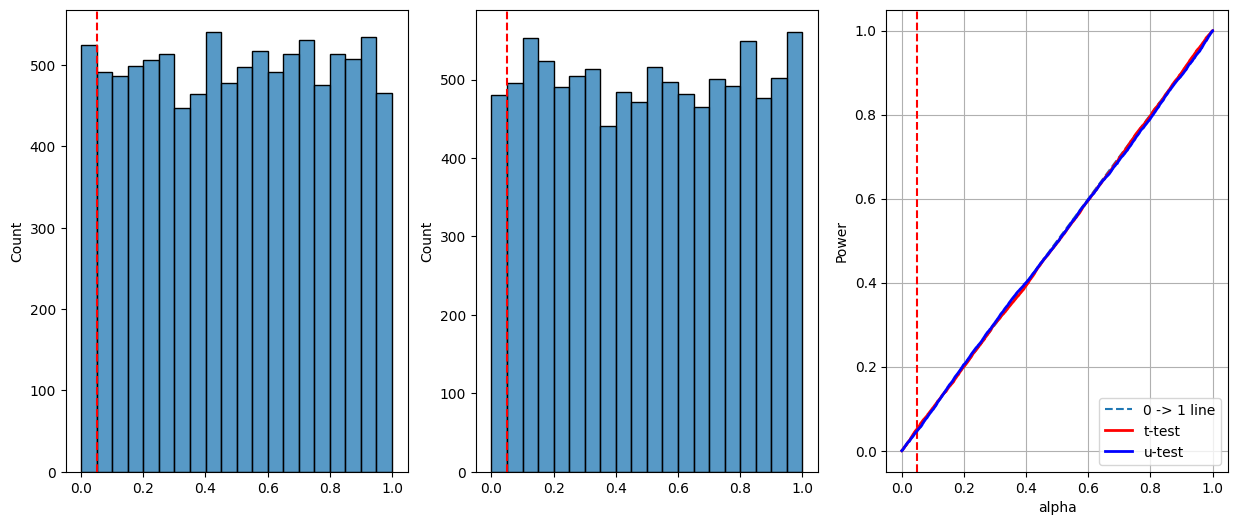

In [ ]:
values_0, values_1 = linearization_of_clicks(clicks_a_1, views_a_1, clicks_a_2, views_a_2)
p_vals_AA_ttest = stats.ttest_ind(values_0.T, values_1.T).pvalue
p_vals_AA_mw = stats.mannwhitneyu(values_0.T, values_1.T).pvalue

print(f"Percentage p-values t-test: {(p_vals_AA_ttest < 0.05).mean()}")
print(f"Percentage p-values MW: {(p_vals_AA_mw < 0.05).mean()}")

fig, ax = plt.subplots(1, 3, figsize=(15, 6))

# 1.
sns.histplot(p_vals_AA_ttest, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2.
sns.histplot(p_vals_AA_mw, ax=ax[1], bins = 20)
ax[1].axvline(0.05, color='r', linestyle='--')

# 3.
ax[2].grid(True)
ax[2].axvline(0.05, color='r', linestyle='--')
ax[2].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[2].set_xlabel('alpha')
ax[2].set_ylabel('Power')
cdf = plot_cdf(p_vals_AA_ttest,'t-test', ax[2], color='r')
cdf = plot_cdf(p_vals_AA_mw,'u-test', ax[2], color='b')
legend = ax[2].legend()


plt.show()

Percentage p-values t-test: 0.2085
Percentage p-values MW: 0.0963


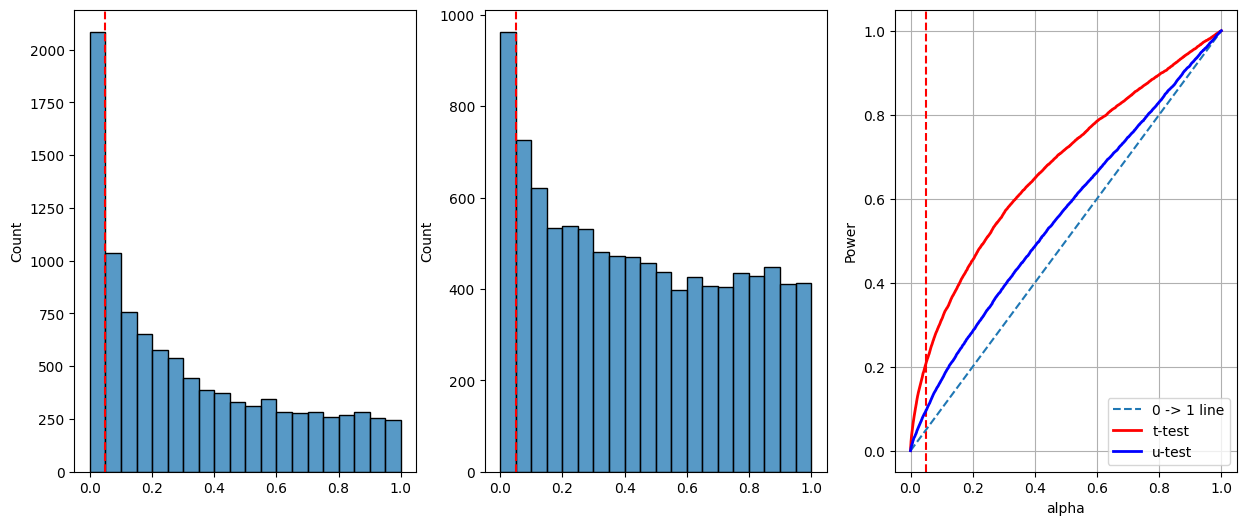

In [ ]:
values_0, values_1 = linearization_of_clicks(clicks_a_1, views_a_1, clicks_b, views_b)
p_vals_AB_ttest = stats.ttest_ind(values_0.T, values_1.T).pvalue
p_vals_AB_mw = stats.mannwhitneyu(values_0.T, values_1.T).pvalue

print(f"Percentage p-values t-test: {(p_vals_AB_ttest < 0.05).mean()}")
print(f"Percentage p-values MW: {(p_vals_AB_mw < 0.05).mean()}")

fig, ax = plt.subplots(1, 3, figsize=(15, 6))

# 1.
sns.histplot(p_vals_AB_ttest, ax=ax[0], bins = 20)
ax[0].axvline(0.05, color='r', linestyle='--')

# 2.
sns.histplot(p_vals_AB_mw, ax=ax[1], bins = 20)
ax[1].axvline(0.05, color='r', linestyle='--')

# 3.
ax[2].grid(True)
ax[2].axvline(0.05, color='r', linestyle='--')
ax[2].plot([0, 1], [0, 1], linestyle = '--', label = '0 -> 1 line')
ax[2].set_xlabel('alpha')
ax[2].set_ylabel('Power')
cdf = plot_cdf(p_vals_AB_ttest,'t-test', ax[2], color='r')
cdf = plot_cdf(p_vals_AB_mw,'u-test', ax[2], color='b')
legend = ax[2].legend()


plt.show()

# Other

In [ ]:
def intra_user_correlation_aware_weights(clicks_0, views_0, views_1):
    """
    0 - control group
    1 - test group
    Calculates weights for UMVUE global ctr estimate for every user in every experiment both in treatment and control groups
    """
    ri = clicks_0 / views_0
    s3 = clicks_0 * (1 - ri) ** 2 + (views_0 - clicks_0) * ri ** 2
    s3 = np.sum(s3, axis=1) / np.sum(views_0 - 1, axis=1)

    rb = np.mean(clicks_0 / views_0, axis=1).reshape(-1, 1)
    s2 = clicks_0 * (1 - rb) ** 2 + (views_0 - clicks_0) * rb ** 2
    s2 = np.sum(s2, axis=1) / (np.sum(views_0, axis=1) - 1)

    rho = np.maximum(0, 1 - s3 / s2).reshape(-1, 1)

    w_0 = views_0 / (1 + (views_0 - 1) * rho)
    w_1 = views_1 / (1 + (views_1 - 1) * rho)
    return w_0, w_1


In [ ]:
def get_smoothed_ctrs(clicks_0, views_0, clicks_1, views_1, smothing_factor=200):
    """
    0 - control group
    1 - test group
    Calculates smoothed ctr for every user in every experiment both in treatment and control groups
    """
    global_ctr = (np.sum(clicks_0, axis=1) / np.sum(views_0, axis=1)).reshape(-1, 1)
    ctrs_0 = (clicks_0 + smothing_factor * global_ctr) / (views_0 + smothing_factor)
    ctrs_1 = (clicks_1 + smothing_factor * global_ctr) / (views_1 + smothing_factor)
    return ctrs_0, ctrs_1
